# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

This project examines the relationship between public school locations and the socioeconomic conditions of the neighborhoods in which those schools are located. Using public school location data and school neighborhood poverty estimates from the U.S. Department of Education available on data.gov, the datasets are combined to analyze how neighborhood income-to-poverty ratios vary across schools and geographic regions. The goal is to identify spatial and socioeconomic patterns that may highlight differences in economic conditions surrounding public schools.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: *FILL IN* (e.g., CSV File.)

Method: *FILL IN* (e.g., The data was gathered using the "Downloading files" method from X source.)

Dataset variables:

*   *Variable 1 FILL IN* (e.g., H_MEAN: Mean hourly wage)
*   *Variable 2 FILL IN*

In [14]:
Name of dataset: School Neighborhood Poverty Estimates - Current
Type: CSV file
Method: Manual download from data.gov (U.S. Department of Education / NCES).
Dataset variables:  
    Variable 1: School ID - Unique NCES (National Center for Education Statistics) identifier for each public school.
    Variable 2: IPR_EST - Estimated income-to-poverty ratio (IPR) for the neighborhood surrounding each school.
    Variable 3: School Year - Academic year the estimate applies to.

SyntaxError: invalid syntax (3120901301.py, line 1)

In [5]:
#Because the workspace does not support uploading local files, a raw copy of the manually downloaded CSV was saved within the notebook environment to allow me to work on it within the environment.
import pandas as pd
    
poverty_df = pd.read_csv("https://data-nces.opendata.arcgis.com/datasets/nces::school-neighborhood-poverty-estimates-current.csv?where=1=1&outSR=%7B%22latestWkid%22%3A3857%2C%22wkid%22%3A102100%7D", low_memory=False)
poverty_df.to_csv("raw_school_neighborhood_poverty.csv", index=False)

#Verify file showing
poverty_df.head()

,OBJECTID,School ID,Name,IPR_EST,IPR_SE,LAT,LON,LEAID,School Year,x,y
0,1,10000500870,Albertville Middle School,206,42,34.2602,-86.206200,100005,2021-2022,-86.206200,34.2602
1,2,10000500871,Albertville High School,201,43,34.2622,-86.204900,100005,2021-2022,-86.204900,34.2622
2,3,10000500879,Albertville Intermediate School,164,43,34.2733,-86.220100,100005,2021-2022,-86.220100,34.2733
3,4,10000500889,Albertville Elementary School,225,54,34.2527,-86.221806,100005,2021-2022,-86.221806,34.2527
4,5,10000501616,Albertville Kindergarten and PreK,278,93,34.2898,-86.193300,100005,2021-2022,-86.193300,34.2898


#### Dataset 2

Type: *FILL IN* (e.g., CSV File.)

Method: *FILL IN* (e.g., The data was gathered using the "API" method from Y source.)

Dataset variables:

*   *Variable 1 FILL IN* (e.g., H_MEAN: Mean hourly wage)
*   *Variable 2 FILL IN*

In [2]:
Name of dataset: Public School Locations - Current
Type: CSV file
Method: Programmatic file download from data.gov using Python (loaded into pandas).
Dataset Variables:
    Variable 1: NCESSCH - Unique NCES identifier for each public school
    Variable 2: STATE: U.S. state where the school is located
    Variable 3: LAT / LON - Geographic coordinates of the school
    Variable 4: SCHOOLYEAR - Academic year of the school record

SyntaxError: invalid syntax (71372479.py, line 1)

In [6]:
#Code to download programmatically and save locally
import pandas as pd

locations_url = "https://data-nces.opendata.arcgis.com/api/download/v1/items/0e8df2dcbbc54e13833344e2ca8c0fa4/csv?layers=0"
locations_df = pd.read_csv(locations_url, low_memory=False)
locations_df.to_csv("raw_public_school_locations.csv", index=False)

#Verify file showing
locations_df.head()

,X,Y,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,...,NMCBSA,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,SCHOOLYEAR
0,-86.206200,34.2602,1,10000500870,100005,Albertville Middle School,1,600 E Alabama Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
1,-86.204900,34.2622,2,10000500871,100005,Albertville High School,1,402 E McCord Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
2,-86.220100,34.2733,3,10000500879,100005,Albertville Intermediate School,1,901 W McKinney Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
3,-86.221806,34.2527,4,10000500889,100005,Albertville Elementary School,1,145 West End Drive,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
4,-86.193300,34.2898,5,10000501616,100005,Albertville Kindergarten and PreK,1,257 Country Club Rd,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [ ]:
The raw versions of both datasets were saved locally in the notebook environment before making changes.


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [7]:
#FILL IN - Inspecting the dataframe visually
#Inspect column data types to identify potential quality issues such as
#improperly typed variables or fields that may not be analytically useful.
poverty_df.to_csv("raw_school_neighborhood_poverty.csv", index=False)
poverty_df.dtypes



OBJECTID         int64
School ID        int64
Name            object
IPR_EST          int64
IPR_SE           int64
LAT            float64
LON            float64
LEAID            int64
School Year     object
x              float64
y              float64
dtype: object

In [8]:
locations_df.to_csv("raw_public_school_locations.csv", index=False)
locations_df.dtypes

X             float64
Y             float64
OBJECTID        int64
NCESSCH         int64
LEAID           int64
NAME           object
OPSTFIPS        int64
STREET         object
CITY           object
STATE          object
ZIP             int64
STFIP           int64
CNTY            int64
NMCNTY         object
LOCALE          int64
LAT           float64
LON           float64
CBSA           object
NMCBSA         object
CBSATYPE        int64
CSA            object
NMCSA          object
NECTA          object
NMNECTA        object
CD              int64
SLDL           object
SLDU           object
SCHOOLYEAR     object
dtype: object

In [9]:
#FILL IN - Inspecting the dataframe programmatically
#Inspect the distribution of the School Year field to determine whether it
#provides meaningful variation or depth for analysis.
poverty_df["School Year"].value_counts().head()

School Year
2021-2022    101146
Name: count, dtype: int64

In [10]:
#Compare the reporting year in the school locations dataset to assess
#alignment between datasets prior to merging.
locations_df["SCHOOLYEAR"].value_counts().head()

SCHOOLYEAR
2022-2023    102268
Name: count, dtype: int64

Issue and justification: 

The School Year variable is stored as an object data type and represents a reporting period rather than a continuous or comparable time attribute. Programmatic inspection shows that all records in the poverty dataset correspond to the 2021–2022 academic year, while the school locations dataset corresponds to 2022–2023. Because neither dataset contains multiple years internally—and the years do not align across datasets—this variable does not contribute analytical value. Retaining it could also mislead interpretation, so the column is best removed to preserve data validity.

### Quality Issue 2:

In [11]:
#FILL IN - Inspecting the dataframe visually
locations_raw = pd.read_csv("raw_public_school_locations.csv", low_memory=False)
# Visually inspect latitude and longitude columns to identify possible duplication
# between coordinate systems.
locations_raw[["LAT", "LON", "X", "Y"]].head()


,LAT,LON,X,Y
0,34.2602,-86.206200,-86.206200,34.2602
1,34.2622,-86.204900,-86.204900,34.2622
2,34.2733,-86.220100,-86.220100,34.2733
3,34.2527,-86.221806,-86.221806,34.2527
4,34.2898,-86.193300,-86.193300,34.2898


In [12]:
#FILL IN - Inspecting the dataframe programmatically
#Programmatically compare LAT and Y values to confirm whether they represent
#the same geographic information with only floating-point precision differences.
(locations_raw["LAT"] - locations_raw["Y"]).abs().describe()

count    1.022680e+05
mean     2.254242e-10
std      1.294058e-10
min      0.000000e+00
25%      1.140990e-10
50%      2.249010e-10
75%      3.376002e-10
max      4.497025e-10
dtype: float64

Issue and justification: 

The dataset contains redundant geographic coordinate variables (LAT/LON and X/Y) that represent the same school location information. Visual inspection shows near-identical values, and programmatic comparison confirms the differences are negligible and attributable to floating-point precision. Maintaining multiple representations of the same attribute reduces data quality by introducing inconsistency and unnecessary complexity. One authoritative coordinate pair should be retained.



### Tidiness Issue 1:

In [13]:
#FILL IN - Inspecting the dataframe visually
# Visually inspect the column headers of each dataset to assess naming conventions
# and identify inconsistencies that could complicate merging or analysis.
poverty_df.head()



,OBJECTID,School ID,Name,IPR_EST,IPR_SE,LAT,LON,LEAID,School Year,x,y
0,1,10000500870,Albertville Middle School,206,42,34.2602,-86.206200,100005,2021-2022,-86.206200,34.2602
1,2,10000500871,Albertville High School,201,43,34.2622,-86.204900,100005,2021-2022,-86.204900,34.2622
2,3,10000500879,Albertville Intermediate School,164,43,34.2733,-86.220100,100005,2021-2022,-86.220100,34.2733
3,4,10000500889,Albertville Elementary School,225,54,34.2527,-86.221806,100005,2021-2022,-86.221806,34.2527
4,5,10000501616,Albertville Kindergarten and PreK,278,93,34.2898,-86.193300,100005,2021-2022,-86.193300,34.2898


In [14]:
locations_df.head()

,X,Y,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,...,NMCBSA,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,SCHOOLYEAR
0,-86.206200,34.2602,1,10000500870,100005,Albertville Middle School,1,600 E Alabama Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
1,-86.204900,34.2622,2,10000500871,100005,Albertville High School,1,402 E McCord Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
2,-86.220100,34.2733,3,10000500879,100005,Albertville Intermediate School,1,901 W McKinney Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
3,-86.221806,34.2527,4,10000500889,100005,Albertville Elementary School,1,145 West End Drive,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
4,-86.193300,34.2898,5,10000501616,100005,Albertville Kindergarten and PreK,1,257 Country Club Rd,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023


In [15]:
#FILL IN - Inspecting the dataframe programmatically
# Compare column names programmatically to confirm inconsistent naming patterns
# across datasets that represent the same conceptual variables.
poverty_df.columns



Index(['OBJECTID', 'School ID', 'Name', 'IPR_EST', 'IPR_SE', 'LAT', 'LON',
       'LEAID', 'School Year', 'x', 'y'],
      dtype='object')

In [16]:
locations_df.columns

Index(['X', 'Y', 'OBJECTID', 'NCESSCH', 'LEAID', 'NAME', 'OPSTFIPS', 'STREET',
       'CITY', 'STATE', 'ZIP', 'STFIP', 'CNTY', 'NMCNTY', 'LOCALE', 'LAT',
       'LON', 'CBSA', 'NMCBSA', 'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA',
       'CD', 'SLDL', 'SLDU', 'SCHOOLYEAR'],
      dtype='object')

Issue and justification: The two datasets use inconsistent column naming conventions. (e.g., School ID vs NCESSCH, School Year vs SCHOOLYEAR). Visual inspection and programmatic review of column headers confirm these inconsistencies. This violates tidy data principles by making variables harder to reference consistently and complicating dataset merging. Column names should be standardized prior to combining the datasets.


### Tidiness Issue 2: 

In [17]:
#FILL IN - Inspecting the dataframe visually
poverty_df.head()



,OBJECTID,School ID,Name,IPR_EST,IPR_SE,LAT,LON,LEAID,School Year,x,y
0,1,10000500870,Albertville Middle School,206,42,34.2602,-86.206200,100005,2021-2022,-86.206200,34.2602
1,2,10000500871,Albertville High School,201,43,34.2622,-86.204900,100005,2021-2022,-86.204900,34.2622
2,3,10000500879,Albertville Intermediate School,164,43,34.2733,-86.220100,100005,2021-2022,-86.220100,34.2733
3,4,10000500889,Albertville Elementary School,225,54,34.2527,-86.221806,100005,2021-2022,-86.221806,34.2527
4,5,10000501616,Albertville Kindergarten and PreK,278,93,34.2898,-86.193300,100005,2021-2022,-86.193300,34.2898


In [18]:
locations_df.head()

,X,Y,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,...,NMCBSA,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,SCHOOLYEAR
0,-86.206200,34.2602,1,10000500870,100005,Albertville Middle School,1,600 E Alabama Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
1,-86.204900,34.2622,2,10000500871,100005,Albertville High School,1,402 E McCord Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
2,-86.220100,34.2733,3,10000500879,100005,Albertville Intermediate School,1,901 W McKinney Ave,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
3,-86.221806,34.2527,4,10000500889,100005,Albertville Elementary School,1,145 West End Drive,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023
4,-86.193300,34.2898,5,10000501616,100005,Albertville Kindergarten and PreK,1,257 Country Club Rd,Albertville,AL,...,"Albertville, AL",2,N,N,N,N,104,01026,01009,2022-2023


In [19]:
#FILL IN - Inspecting the dataframe programmatically
# Inspect dataset dimensions to understand the overall structure and
# assess whether both datasets contain a large number of non-essential variables.
poverty_df.shape, locations_df.shape




((101146, 11), (102268, 28))

Issue and justification: 

Both datasets include administrative and system-generated identifier variables (such as OBJECTID) and additional metadata fields that are not required to answer the research question. Visual inspection of dataset previews and programmatic review of dataset dimensions confirm the presence of many non-essential columns. Retaining unnecessary variables reduces data tidiness by adding structural clutter and increasing complexity during cleaning and merging. These columns should be removed so the final dataset contains only analytically relevant variables.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [20]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
poverty_clean = poverty_df.copy()



In [21]:
locations_clean = locations_df.copy()

### **Quality Issue 1: FILL IN**

In [22]:
# FILL IN - Apply the cleaning strategy
# Remove the School Year fields from both datasets since they contain
# do not support specific time-based analysis.
poverty_clean = poverty_clean.drop(columns=["School Year"])

In [23]:
locations_clean = locations_clean.drop(columns=["SCHOOLYEAR"])

In [24]:
# FILL IN - Validate the cleaning was successful
# Expected output to be False
"School Year" in poverty_clean.columns


False

In [25]:
# Expected output to be False
"SCHOOLYEAR" in locations_clean.columns

False

Justification: The School Year column was removed from the poverty dataset because it contains a single constant value (2021–2022) and does not provide meaningful insight for analysis. Additionally, the locations dataset uses a different year value (2022–2023), so retaining these year fields could create confusion or imply that the merged dataset represents the same reporting year across both sources when it does not. Removing the column improves clarity and prevents misleading time-based interpretation while preserving the variables needed for the research question.

### **Quality Issue 2: FILL IN**

In [26]:
#FILL IN - Apply the cleaning strategy
# Remove redundant X and Y coordinate columns from the locations dataset.
# Latitude and longitude will be retained from a single source
# to reduce redundancy and improve consistency.
locations_clean = locations_clean.drop(columns=["X", "Y"])

In [27]:
#FILL IN - Validate the cleaning was successful
#Expected result []
[col for col in ["X", "Y"] if col in locations_clean.columns]


[]

Justification: The X and Y variables were removed because they duplicate the geographic information already represented by LAT and LON from the Poverty dataset. Retaining a single coordinate representation improves data consistency, reduces redundancy, and lowers the risk of ambiguity during analysis and visualization.

### **Tidiness Issue 1: FILL IN**

In [28]:
#FILL IN - Apply the cleaning strategy
poverty_clean.columns = (
    poverty_clean.columns
    .str.lower()
    .str.replace(" ", "_")
)



In [29]:
locations_clean.columns = (
    locations_clean.columns
    .str.lower()
)

In [30]:
#FILL IN - Validate the cleaning was successful
poverty_clean.columns



Index(['objectid', 'school_id', 'name', 'ipr_est', 'ipr_se', 'lat', 'lon',
       'leaid', 'x', 'y'],
      dtype='object')

In [31]:
locations_clean.columns

Index(['objectid', 'ncessch', 'leaid', 'name', 'opstfips', 'street', 'city',
       'state', 'zip', 'stfip', 'cnty', 'nmcnty', 'locale', 'lat', 'lon',
       'cbsa', 'nmcbsa', 'cbsatype', 'csa', 'nmcsa', 'necta', 'nmnecta', 'cd',
       'sldl', 'sldu'],
      dtype='object')

Justification: Column names in both datasets were standardized to a consistent, machine-friendly format by converting all names to lowercase and replacing spaces with underscores. This improves data tidiness by making variables easier to reference programmatically and reducing the risk of errors during transformation and merging. Standardized naming also improves readability and consistency across the combined dataset.

### **Tidiness Issue 2: FILL IN**

In [32]:
#FILL IN - Apply the cleaning strategy
poverty_clean = poverty_clean.drop(columns=["objectid"])


In [37]:
locations_clean = locations_clean.drop(
    columns=[
        "objectid",
        "opstfips",
        "cbsa",
        "nmcbsa",
        "cbsatype",
        "csa",
        "nmcsa",
        "necta",
        "nmnecta",
        "cd",
        "sldl",
        "sldu"
    ],
    errors="ignore"
)

In [38]:
#FILL IN - Validate the cleaning was successful
poverty_clean.columns


Index(['school_id', 'name', 'ipr_est', 'ipr_se', 'lat', 'lon', 'leaid', 'x',
       'y'],
      dtype='object')

In [39]:
locations_clean.columns


Index(['ncessch', 'leaid', 'name', 'street', 'city', 'state', 'zip', 'stfip',
       'cnty', 'nmcnty', 'locale', 'lat', 'lon'],
      dtype='object')

Justification: Administrative and system-generated variables that were not required for the research question or dataset merging were removed from both datasets. Visual inspection and column-level review confirmed that these variables did not contribute meaningful analytical information and added unnecessary structural complexity. Removing these fields improves data tidiness by producing a cleaner, more focused dataset while preserving all variables needed for analysis and combination.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [40]:
#FILL IN - Remove unnecessary variables and combine datasets
poverty_final = poverty_clean[
    ["school_id", "name", "ipr_est", "ipr_se", "lat", "lon", "leaid"]
].copy()

In [41]:
locations_final = locations_clean[
    ["ncessch", "state", "street", "city", "zip", "locale", "lat", "lon", "leaid"]
].copy()

In [42]:
combined_df = poverty_final.merge(
    locations_final,
    left_on="school_id",
    right_on="ncessch",
    how="left",
    suffixes=("_poverty", "_location")
)

In [43]:
combined_df = combined_df.drop(columns=["ncessch"])

In [44]:
#Check to make sure merged
print("Combined shape:", combined_df.shape)
print("Missing location matches:", combined_df["state"].isna().sum())
combined_df.head()


Combined shape: (101146, 15)
Missing location matches: 926


,school_id,name,ipr_est,ipr_se,lat_poverty,lon_poverty,leaid_poverty,state,street,city,zip,locale,lat_location,lon_location,leaid_location
0,10000500870,Albertville Middle School,206,42,34.2602,-86.206200,100005,AL,600 E Alabama Ave,Albertville,35950.0,32.0,34.2602,-86.206200,100005.0
1,10000500871,Albertville High School,201,43,34.2622,-86.204900,100005,AL,402 E McCord Ave,Albertville,35950.0,32.0,34.2622,-86.204900,100005.0
2,10000500879,Albertville Intermediate School,164,43,34.2733,-86.220100,100005,AL,901 W McKinney Ave,Albertville,35950.0,32.0,34.2733,-86.220100,100005.0
3,10000500889,Albertville Elementary School,225,54,34.2527,-86.221806,100005,AL,145 West End Drive,Albertville,35950.0,32.0,34.2527,-86.221806,100005.0
4,10000501616,Albertville Kindergarten and PreK,278,93,34.2898,-86.193300,100005,AL,257 Country Club Rd,Albertville,35951.0,32.0,34.2898,-86.193300,100005.0


In [45]:
combined_df.columns


Index(['school_id', 'name', 'ipr_est', 'ipr_se', 'lat_poverty', 'lon_poverty',
       'leaid_poverty', 'state', 'street', 'city', 'zip', 'locale',
       'lat_location', 'lon_location', 'leaid_location'],
      dtype='object')

In [46]:
combined_df = combined_df.drop(columns=["lat_poverty", "lon_poverty"])

In [47]:
combined_df = combined_df.rename(columns={"lat_location": "lat", "lon_location": "lon"})

In [48]:
combined_df = combined_df.drop(columns=["leaid_poverty"])

In [49]:
combined_df = combined_df.rename(columns={"leaid_location": "leaid"})

In [43]:
print("Final shape:", combined_df.shape)
print("Columns:", combined_df.columns.tolist())
print("Missing location matches (state):", combined_df["state"].isna().sum())

combined_df.head()


Final shape: (101146, 12)
Columns: ['school_id', 'name', 'ipr_est', 'ipr_se', 'state', 'street', 'city', 'zip', 'locale', 'lat', 'lon', 'leaid']
Missing location matches (state): 926


,school_id,name,ipr_est,ipr_se,state,street,city,zip,locale,lat,lon,leaid
0,10000500870,Albertville Middle School,206,42,AL,600 E Alabama Ave,Albertville,35950.0,32.0,34.2602,-86.206200,100005.0
1,10000500871,Albertville High School,201,43,AL,402 E McCord Ave,Albertville,35950.0,32.0,34.2622,-86.204900,100005.0
2,10000500879,Albertville Intermediate School,164,43,AL,901 W McKinney Ave,Albertville,35950.0,32.0,34.2733,-86.220100,100005.0
3,10000500889,Albertville Elementary School,225,54,AL,145 West End Drive,Albertville,35950.0,32.0,34.2527,-86.221806,100005.0
4,10000501616,Albertville Kindergarten and PreK,278,93,AL,257 Country Club Rd,Albertville,35951.0,32.0,34.2898,-86.193300,100005.0


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [50]:
import os

# Save raw dataset snapshots (unchanged) so there is always a recoverable version.
poverty_df.to_csv("raw_school_neighborhood_poverty.csv", index=False)
locations_df.to_csv("raw_public_school_locations.csv", index=False)

# Save cleaned intermediate datasets
poverty_clean.to_csv("cleaned_school_neighborhood_poverty.csv", index=False)
locations_clean.to_csv("cleaned_public_school_locations.csv", index=False)

# Save final cleaned combined dataset
combined_df.to_csv("cleaned_school_poverty_locations.csv", index=False)

# Validate that files were written and capture basic record counts for documentation.
files = [
    "raw_school_neighborhood_poverty.csv",
    "raw_public_school_locations.csv",
    "cleaned_school_neighborhood_poverty.csv",
    "cleaned_public_school_locations.csv",
    "cleaned_school_poverty_locations.csv"
]

for f in files:
    print(f"{f}: exists={os.path.exists(f)}")
    
print("\nFinal cleaned dataset shape:", combined_df.shape)
print("Saved cleaned_school_poverty_locations.csv")


raw_school_neighborhood_poverty.csv: exists=True
raw_public_school_locations.csv: exists=True
cleaned_school_neighborhood_poverty.csv: exists=True
cleaned_public_school_locations.csv: exists=True
cleaned_school_poverty_locations.csv: exists=True

Final cleaned dataset shape: (101146, 12)
Saved cleaned_school_poverty_locations.csv


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* How do neighborhood poverty levels vary across public schools and geographic areas in the United States?

In [51]:
#Visual 1 - FILL IN
state_poverty = (
    combined_df
    .groupby("state", as_index=False)
    .agg(avg_ipr=("ipr_est", "mean"))
)


In [52]:
# Preview the aggregated results to confirm expected structure.
state_poverty.head()


,state,avg_ipr
0,AK,302.159136
1,AL,260.339286
2,AR,243.158187
3,AZ,283.594838
4,CA,361.818217


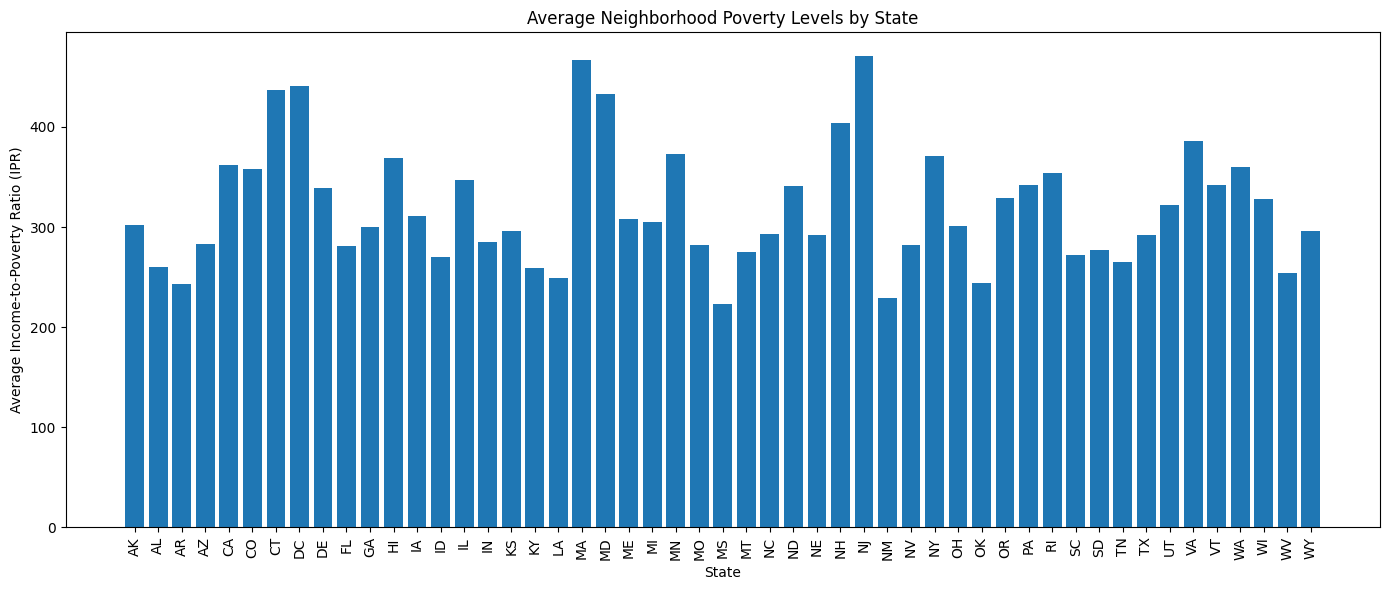

In [53]:
import matplotlib.pyplot as plt

# Visualize average neighborhood poverty levels by state.
# This bar chart highlights broad geographic variation across the U.S.

plt.figure(figsize=(14, 6))
plt.bar(state_poverty["state"], state_poverty["avg_ipr"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Average Income-to-Poverty Ratio (IPR)")
plt.title("Average Neighborhood Poverty Levels by State")

plt.tight_layout()
plt.show()


*Answer to research question:* 
This visualization shows that neighborhood poverty levels around public schools vary substantially by state. Some states exhibit higher average income-to-poverty ratios, suggesting schools are more often located in higher-income neighborhoods, while other states show lower averages. This demonstrates meaningful geographic variation in the economic contexts surrounding public schools across the United States.

<Figure size 1200x600 with 0 Axes>

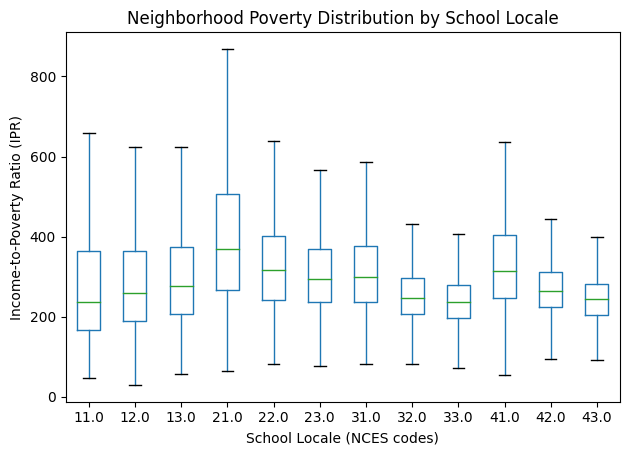

In [54]:
#Visual 2 - FILL IN
import matplotlib.pyplot as plt

locale_poverty = combined_df.dropna(subset=["locale"])

plt.figure(figsize=(12, 6))
locale_poverty.boxplot(
    column="ipr_est",
    by="locale",
    grid=False,
    showfliers=False
)

plt.xlabel("School Locale (NCES codes)")
plt.ylabel("Income-to-Poverty Ratio (IPR)")
plt.title("Neighborhood Poverty Distribution by School Locale")
plt.suptitle("") 
plt.tight_layout()
plt.show()



*Answer to research question:* 

This visualization compares the distribution of neighborhood income-to-poverty ratios across NCES school locale categories. The differences in medians and spreads indicate that schools in urban, suburban, town, and rural settings experience distinct economic environments. This suggests that neighborhood poverty varies not only by geographic region but also by community type.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* 
If more time were available, additional work could focus on reconciling year differences between datasets to improve temporal alignment. Further analysis could examine neighborhood poverty patterns at finer geographic levels, such as cities or school districts. Incorporating enrollment or student demographic data could also provide deeper insight into how neighborhood economic conditions relate to school characteristics.